In [4]:
# Script to perform a back-to-the-envelop analysis 
# Estimate the impact of taking into account the ascending particle stocks in POC flux estimates
# Compare with sediment traps data collected during APERO cruise

In [92]:
import pandas as pd 
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import re
import math
import numpy as np
import re
from scipy.interpolate import interp1d
import string
pd.options.mode.chained_assignment = None
pd.set_option('display.max_columns', None)

In [93]:
def clean_float(x):
    # Format with 3 decimals, then strip trailing zeros and dot
    return ('{:.3f}'.format(x)).rstrip('0').rstrip('.')

def geom_mean(size_str):
    low, high = map(float, size_str.split('-'))
    return (low * high) ** 0.5

def bin_midpoint(x, precision):
    lower_edge = math.floor(x / precision) * precision
    return lower_edge + precision


# Import sediment traps data from APERO cruise (Pourquoi Pas?)

In [94]:
ST_POC_fluxes = pd.read_csv('/home/aaccardo/these_alex/Papers/Rising_stars/Data/POC_fluxes/POC_fluxes_PSS_drifting_traps.csv', delimiter = ';')
ST_POC_fluxes = ST_POC_fluxes.rename(columns={'Depth_m': 'Pressure [dbar]'})
ST_POC_fluxes.head(3)

,Site,Pressure [dbar],Mean_flux_mg_m2_d,Sd_flux,Integrated_time_d,mean_POC_tot_mg_trap,sd_POC_tot_mg_trap
0,ST01_PSS1,52,124.364158,7.901037,3.1875,3.113403,0.197799
1,ST01_PSS1,77,89.131584,4.331640,3.1875,2.231371,0.108441
2,ST01_PSS1,102,79.486859,4.227863,3.1875,1.989919,0.105843


# Import UVP6-CTD casts data at all PSS

In [95]:
UVP_PSS_data = pd.read_csv('/home/aaccardo/these_alex/Papers/Rising_stars/Data/POC_fluxes/ecopart_APERO_PP_PSS.csv')
UVP_PSS_data = UVP_PSS_data.filter(items=['Profile', 'Site', 'Pressure [dbar]']).join(
    UVP_PSS_data.filter(like='Part conc frac')
)
UVP_PSS_data.head(3)

,Profile,Site,Pressure [dbar],Part conc frac [#/l] (ESD: 0.001-0.00126 mm),Part conc frac [#/l] (ESD: 0.00126-0.00159 mm),Part conc frac [#/l] (ESD: 0.00159-0.002 mm),Part conc frac [#/l] (ESD: 0.002-0.00252 mm),Part conc frac [#/l] (ESD: 0.00252-0.00317 mm),Part conc frac [#/l] (ESD: 0.00317-0.004 mm),Part conc frac [#/l] (ESD: 0.004-0.00504 mm),Part conc frac [#/l] (ESD: 0.00504-0.00635 mm),Part conc frac [#/l] (ESD: 0.00635-0.008 mm),Part conc frac [#/l] (ESD: 0.008-0.0101 mm),Part conc frac [#/l] (ESD: 0.0101-0.0127 mm),Part conc frac [#/l] (ESD: 0.0127-0.016 mm),Part conc frac [#/l] (ESD: 0.016-0.0202 mm),Part conc frac [#/l] (ESD: 0.0202-0.0254 mm),Part conc frac [#/l] (ESD: 0.0254-0.032 mm),Part conc frac [#/l] (ESD: 0.032-0.040299999999999996 mm),Part conc frac [#/l] (ESD: 0.040299999999999996-0.0508 mm),Part conc frac [#/l] (ESD: 0.0508-0.064 mm),Part conc frac [#/l] (ESD: 0.064-0.08059999999999999 mm),Part conc frac [#/l] (ESD: 0.08059999999999999-0.102 mm),Part conc frac [#/l] (ESD: 0.102-0.128 mm),Part conc frac [#/l] (ESD: 0.128-0.161 mm),Part conc frac [#/l] (ESD: 0.161-0.203 mm),Part conc frac [#/l] (ESD: 0.203-0.256 mm),Part conc frac [#/l] (ESD: 0.256-0.323 mm),Part conc frac [#/l] (ESD: 0.323-0.406 mm),Part conc frac [#/l] (ESD: 0.406-0.512 mm),Part conc frac [#/l] (ESD: 0.512-0.645 mm),Part conc frac [#/l] (ESD: 0.645-0.813 mm),Part conc frac [#/l] (ESD: 0.813-1.02 mm),Part conc frac [#/l] (ESD: 1.02-1.29 mm),Part conc frac [#/l] (ESD: 1.29-1.63 mm),Part conc frac [#/l] (ESD: 1.63-2.05 mm),Part conc frac [#/l] (ESD: 2.05-2.58 mm),Part conc frac [#/l] (ESD: 2.58-3.25 mm),Part conc frac [#/l] (ESD: 3.25-4.1 mm),Part conc frac [#/l] (ESD: 4.1-5.16 mm),Part conc frac [#/l] (ESD: 5.16-6.5 mm),Part conc frac [#/l] (ESD: 6.5-8.19 mm),Part conc frac [#/l] (ESD: 8.19-10.3 mm),Part conc frac [#/l] (ESD: 10.3-13 mm),Part conc frac [#/l] (ESD: 13-16.4 mm),Part conc frac [#/l] (ESD: 16.4-20.6 mm),Part conc frac [#/l] (ESD: 20.6-26 mm),Part conc frac [#/l] (ESD: >26 mm)
0,APERO_CTD_UVP6_PP_003,ST01,7.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3407.777778,295.066335,78.706468,48.291874,43.598673,38.391376,17.495854,6.799337,2.371476,1.500829,0.597015,0.248756,0.140962,0.082919,0.008292,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,APERO_CTD_UVP6_PP_003,ST01,12.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3370.865672,289.582090,73.761194,45.417910,44.089552,40.298507,18.985075,7.835821,2.626866,1.283582,0.671642,0.432836,0.582090,0.119403,0.014925,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,APERO_CTD_UVP6_PP_003,ST01,17.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3291.727079,295.191898,83.176972,52.611940,51.599147,48.869936,26.343284,12.718550,3.582090,1.130064,0.660981,0.639659,0.501066,0.170576,0.010661,0.021322,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Rearrange column names

In [96]:
pattern = r'Part conc frac.*\(ESD:\s*([\d\.]+)-([\d\.]+)\s*mm\)'

new_names = {}
for col in UVP_PSS_data.columns:
    match = re.search(pattern, col)
    if match:
        low = float(match.group(1)) * 1000
        high = float(match.group(2)) * 1000
        new_name = f"{clean_float(low)}-{clean_float(high)}"
        new_names[col] = new_name

UVP_PSS_data = UVP_PSS_data.rename(columns=new_names)
UVP_PSS_data = UVP_PSS_data.loc[:, ~UVP_PSS_data.columns.str.contains('>')]
UVP_PSS_data

,Profile,Site,Pressure [dbar],1-1.26,1.26-1.59,1.59-2,2-2.52,2.52-3.17,3.17-4,4-5.04,5.04-6.35,6.35-8,8-10.1,10.1-12.7,12.7-16,16-20.2,20.2-25.4,25.4-32,32-40.3,40.3-50.8,50.8-64,64-80.6,80.6-102,102-128,128-161,161-203,203-256,256-323,323-406,406-512,512-645,645-813,813-1020,1020-1290,1290-1630,1630-2050,2050-2580,2580-3250,3250-4100,4100-5160,5160-6500,6500-8190,8190-10300,10300-13000,13000-16400,16400-20600,20600-26000
0,APERO_CTD_UVP6_PP_003,ST01,7.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3407.777778,295.066335,78.706468,48.291874,43.598673,38.391376,17.495854,6.799337,2.371476,1.500829,0.597015,0.248756,0.140962,0.082919,0.008292,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
1,APERO_CTD_UVP6_PP_003,ST01,12.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3370.865672,289.582090,73.761194,45.417910,44.089552,40.298507,18.985075,7.835821,2.626866,1.283582,0.671642,0.432836,0.582090,0.119403,0.014925,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
2,APERO_CTD_UVP6_PP_003,ST01,17.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3291.727079,295.191898,83.176972,52.611940,51.599147,48.869936,26.343284,12.718550,3.582090,1.130064,0.660981,0.639659,0.501066,0.170576,0.010661,0.021322,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
3,APERO_CTD_UVP6_PP_003,ST01,22.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3250.597015,285.174129,78.432836,53.669154,50.945274,48.159204,26.368159,15.460199,6.194030,2.549751,0.733831,0.211443,0.062189,0.037313,0.000000,0.012438,0.037313,0.012438,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
4,APERO_CTD_UVP6_PP_003,ST01,27.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3162.957938,275.115332,75.535957,50.393487,48.873813,45.264586,25.061058,15.522388,6.146540,2.265943,0.895522,0.366350,0.122117,0.000000,0.000000,0.013569,0.040706,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40041,APERO_CTD_UVP6_PP_128,ST42,517.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2877.014925,179.552239,26.069652,15.472637,11.210614,8.922056,4.129353,2.868988,1.674959,0.895522,0.364842,0.165837,0.165837,0.033167,0.000000,0.049751,0.000000,0.000000,0.0,0.082919,0.016584,0.0,0.0,0.0,0.0,0.0,0.0
40042,APERO_CTD_UVP6_PP_128,ST42,522.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2848.291874,176.965174,26.252073,15.787728,11.873964,9.751244,4.477612,2.885572,1.509121,0.945274,0.514096,0.132670,0.033167,0.000000,0.049751,0.033167,0.033167,0.066335,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
40043,APERO_CTD_UVP6_PP_128,ST42,527.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2926.475954,199.900498,34.535655,21.409619,16.492537,13.109453,6.243781,3.872305,2.048093,1.210614,0.605307,0.215589,0.190713,0.165837,0.058043,0.066335,0.008292,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
40044,APERO_CTD_UVP6_PP_128,ST42,532.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2848.591418,177.583955,24.412313,15.177239,11.156716,9.617537,5.354478,3.619403,1.847015,1.231343,0.447761,0.167910,0.093284,0.027985,0.055970,0.018657,0.000000,0.009328,0.0,0.000000,0.009328,0.0,0.0,0.0,0.0,0.0,0.0


# Pivot the dataframe

In [97]:
size_cols = [c for c in UVP_PSS_data.columns if c not in ['Site', 'Pressure [dbar]']]

# Melt the DataFrame
df_melted = UVP_PSS_data.melt(
    id_vars=['Profile', 'Site', 'Pressure [dbar]'],   # columns to keep
    value_vars=size_cols,                  # columns to unpivot
    var_name='size_classes',                 # new column for former column names
    value_name='conc_nb_L'                 # new column for values
)

# Compute the mid point of each size class
df_melted['size_classes_mid'] = df_melted['size_classes'].apply(geom_mean)


UVP_part_conc_PSS = df_melted

# Convert particle abundances to nb/m3
UVP_part_conc_PSS['conc_nb_m3'] = UVP_part_conc_PSS['conc_nb_L']*1000

UVP_part_conc_PSS

,Profile,Site,Pressure [dbar],size_classes,conc_nb_L,size_classes_mid,conc_nb_m3
0,APERO_CTD_UVP6_PP_003,ST01,7.5,1-1.26,0.0,1.122497,0.0
1,APERO_CTD_UVP6_PP_003,ST01,12.5,1-1.26,0.0,1.122497,0.0
2,APERO_CTD_UVP6_PP_003,ST01,17.5,1-1.26,0.0,1.122497,0.0
3,APERO_CTD_UVP6_PP_003,ST01,22.5,1-1.26,0.0,1.122497,0.0
4,APERO_CTD_UVP6_PP_003,ST01,27.5,1-1.26,0.0,1.122497,0.0
...,...,...,...,...,...,...,...
1762019,APERO_CTD_UVP6_PP_128,ST42,517.5,20600-26000,0.0,23143.033509,0.0
1762020,APERO_CTD_UVP6_PP_128,ST42,522.5,20600-26000,0.0,23143.033509,0.0
1762021,APERO_CTD_UVP6_PP_128,ST42,527.5,20600-26000,0.0,23143.033509,0.0
1762022,APERO_CTD_UVP6_PP_128,ST42,532.5,20600-26000,0.0,23143.033509,0.0


# Create depth bins

In [98]:
depth_bin_width = 25
UVP_part_conc_PSS["depth_binned"] = UVP_part_conc_PSS["Pressure [dbar]"].apply(
    lambda x: int(bin_midpoint(x, precision=depth_bin_width)))

UVP_part_conc_PSS = UVP_part_conc_PSS.drop('Pressure [dbar]', axis=1)
UVP_part_conc_PSS = UVP_part_conc_PSS.rename(columns={'depth_binned': 'Pressure [dbar]'})
UVP_part_conc_PSS = (
    UVP_part_conc_PSS.groupby(['Site', 'Profile', 'Pressure [dbar]', 'size_classes', 'size_classes_mid'])['conc_nb_m3']
    .mean()
    .reset_index()
)
UVP_part_conc_PSS

,Site,Profile,Pressure [dbar],size_classes,size_classes_mid,conc_nb_m3
0,ST01,APERO_CTD_UVP6_PP_003,25,1-1.26,1.122497,0.000000
1,ST01,APERO_CTD_UVP6_PP_003,25,1.26-1.59,1.415415,0.000000
2,ST01,APERO_CTD_UVP6_PP_003,25,1.59-2,1.783255,0.000000
3,ST01,APERO_CTD_UVP6_PP_003,25,10.1-12.7,11.325635,0.000000
4,ST01,APERO_CTD_UVP6_PP_003,25,102-128,114.262855,49997.719735
...,...,...,...,...,...,...
355119,ST42,APERO_CTD_UVP6_PP_128,550,6500-8190,7296.231904,0.000000
355120,ST42,APERO_CTD_UVP6_PP_128,550,8-10.1,8.988882,0.000000
355121,ST42,APERO_CTD_UVP6_PP_128,550,80.6-102,90.670833,28782.900226
355122,ST42,APERO_CTD_UVP6_PP_128,550,813-1020,910.637140,135.968480


# Select data above 1000m

In [99]:
UVP_part_conc_PSS = UVP_part_conc_PSS[UVP_part_conc_PSS['Pressure [dbar]'] <= 1050]
UVP_part_conc_PSS['Pressure [dbar]'].max()

1050

# Estimate carbon content (based on Alldredge et al. 1988 and APERO data)

In [100]:
UVP_part_conc_PSS = UVP_part_conc_PSS[UVP_part_conc_PSS['size_classes_mid'] > 102]

# convert esd in mm
UVP_part_conc_PSS['size_classes_mid_mm'] = UVP_part_conc_PSS['size_classes_mid']/1000

# estimate volume based on ESD
UVP_part_conc_PSS['volume_mm3'] = 4/3 * np.pi * (UVP_part_conc_PSS['size_classes_mid_mm']/2)**3

# Estimate carbon content
UVP_part_conc_PSS['carbon_content_µg_alldredge'] = 0.99 * UVP_part_conc_PSS['volume_mm3']**0.52

# Convert to mg
UVP_part_conc_PSS['carbon_content_mg_alldredge'] = UVP_part_conc_PSS['carbon_content_µg_alldredge'] / 1000
UVP_part_conc_PSS.head(5)

,Site,Profile,Pressure [dbar],size_classes,size_classes_mid,conc_nb_m3,size_classes_mid_mm,volume_mm3,carbon_content_µg_alldredge,carbon_content_µg_APERO,carbon_content_mg_alldredge,carbon_content_mg_APERO
4,ST01,APERO_CTD_UVP6_PP_003,25,102-128,114.262855,49997.719735,0.114263,0.000781,0.023980,0.475769,0.000024,0.000476
5,ST01,APERO_CTD_UVP6_PP_003,25,1020-1290,1147.083258,102.552713,1.147083,0.790284,0.875957,1.898496,0.000876,0.001898
6,ST01,APERO_CTD_UVP6_PP_003,25,10300-13000,11571.516755,0.000000,11.571517,811.277605,32.240616,7.597785,0.032241,0.007598
8,ST01,APERO_CTD_UVP6_PP_003,25,128-161,143.554868,47558.161573,0.143555,0.001549,0.034234,0.545586,0.000034,0.000546
9,ST01,APERO_CTD_UVP6_PP_003,25,1290-1630,1450.068964,8.469557,1.450069,1.596484,1.262644,2.185174,0.001263,0.002185


# Import proportion of ascending vs descending for each size class

In [101]:
prop_asc_desc = pd.read_csv('/home/aaccardo/these_alex/Papers/Rising_stars/Data/POC_fluxes/prop_vs_size_APERO.csv')
prop_asc_desc = prop_asc_desc.drop(columns=['desc_count', 'asc_count', 'nb_part_tot'])
prop_asc_desc

,size_classes,asc_prop_%,desc_prop_%
0,102-128,42.857143,57.142857
1,128-161,42.968750,57.031250
2,161-203,50.442478,49.557522
3,203-256,48.314607,51.685393
4,256-323,37.113402,62.886598
5,323-406,40.000000,60.000000
6,406-512,29.268293,70.731707
7,512-645,3.030303,96.969697
8,645-813,8.333333,91.666667
9,813-1020,12.500000,87.500000


# Import average sinking and ascending speeds for each size class

In [102]:
desc_speed = pd.read_csv('/home/aaccardo/these_alex/Papers/Rising_stars/Data/POC_fluxes/APERO_desc_speed_mean_size_classes.csv')
desc_speed = desc_speed.drop(columns=['Unnamed: 0'])
desc_speed

,size_classes,mean_desc_speed_m_d,med_desc_speed_m_d
0,102-128,69.534076,66.946792
1,1020-1290,126.859795,120.029994
2,128-161,68.767497,60.602898
3,1290-1630,146.649269,130.198476
4,161-203,78.159176,71.965973
5,1630-2050,118.018830,118.018830
6,203-256,78.894598,69.532599
7,2050-2580,102.882732,102.882732
8,256-323,91.030638,78.257468
9,323-406,93.393854,75.274545


In [103]:
asc_speed = pd.read_csv('/home/aaccardo/these_alex/Papers/Rising_stars/Data/POC_fluxes/APERO_asc_speed_mean_size_classes.csv')
asc_speed

,size_classes,mean_asc_speed_m_d,med_asc_speed_m_d
0,102-128,-72.714441,-69.726468
1,1020-1290,-87.909927,-87.909927
2,128-161,-81.448681,-73.762794
3,161-203,-85.556331,-76.744171
4,203-256,-80.147208,-77.815981
5,256-323,-97.537787,-87.682602
6,323-406,-109.683694,-103.821444
7,406-512,-127.110420,-103.600734
8,512-645,-139.502897,-139.502897
9,645-813,-80.817149,-80.817149


# Create a global merged dataframe 

In [104]:
final_UVP_df = pd.merge(UVP_part_conc_PSS, prop_asc_desc, on = 'size_classes')
final_UVP_df = pd.merge(final_UVP_df, desc_speed, on = 'size_classes')
final_UVP_df = pd.merge(final_UVP_df, asc_speed, on = 'size_classes')
final_UVP_df

,Site,Profile,Pressure [dbar],size_classes,size_classes_mid,conc_nb_m3,size_classes_mid_mm,volume_mm3,carbon_content_µg_alldredge,carbon_content_µg_APERO,carbon_content_mg_alldredge,carbon_content_mg_APERO,asc_prop_%,desc_prop_%,mean_desc_speed_m_d,med_desc_speed_m_d,mean_asc_speed_m_d,med_asc_speed_m_d
0,ST01,APERO_CTD_UVP6_PP_003,25,102-128,114.262855,49997.719735,0.114263,0.000781,0.023980,0.475769,0.000024,0.000476,42.857143,57.142857,69.534076,66.946792,-72.714441,-69.726468
1,ST01,APERO_CTD_UVP6_PP_003,25,1020-1290,1147.083258,102.552713,1.147083,0.790284,0.875957,1.898496,0.000876,0.001898,10.000000,90.000000,126.859795,120.029994,-87.909927,-87.909927
2,ST01,APERO_CTD_UVP6_PP_003,25,128-161,143.554868,47558.161573,0.143555,0.001549,0.034234,0.545586,0.000034,0.000546,42.968750,57.031250,68.767497,60.602898,-81.448681,-73.762794
3,ST01,APERO_CTD_UVP6_PP_003,25,161-203,180.784402,43929.755982,0.180784,0.003094,0.049055,0.626541,0.000049,0.000627,50.442478,49.557522,78.159176,71.965973,-85.556331,-76.744171
4,ST01,APERO_CTD_UVP6_PP_003,25,203-256,227.964910,22298.092869,0.227965,0.006203,0.070435,0.720068,0.000070,0.000720,48.314607,51.685393,78.894598,69.532599,-80.147208,-77.815981
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32555,ST42,APERO_CTD_UVP6_PP_128,550,323-406,362.129811,1801.513919,0.362130,0.024865,0.144992,0.950542,0.000145,0.000951,40.000000,60.000000,93.393854,75.274545,-109.683694,-103.821444
32556,ST42,APERO_CTD_UVP6_PP_128,550,406-512,455.929819,1181.957091,0.455930,0.049624,0.207680,1.091419,0.000208,0.001091,29.268293,70.731707,94.701310,79.354750,-127.110420,-103.600734
32557,ST42,APERO_CTD_UVP6_PP_128,550,512-645,574.665120,499.337693,0.574665,0.099367,0.297990,1.254012,0.000298,0.001254,3.030303,96.969697,87.408184,68.739030,-139.502897,-139.502897
32558,ST42,APERO_CTD_UVP6_PP_128,550,645-813,724.144323,197.297058,0.724144,0.198826,0.427407,1.440615,0.000427,0.001441,8.333333,91.666667,88.863226,88.910404,-80.817149,-80.817149


In [105]:
df = final_UVP_df[['size_classes', 'med_desc_speed_m_d', 'med_asc_speed_m_d']].drop_duplicates()
df

,size_classes,med_desc_speed_m_d,med_asc_speed_m_d
0,102-128,66.946792,-69.726468
1,1020-1290,120.029994,-87.909927
2,128-161,60.602898,-73.762794
3,161-203,71.965973,-76.744171
4,203-256,69.532599,-77.815981
5,256-323,78.257468,-87.682602
6,323-406,75.274545,-103.821444
7,406-512,79.354750,-103.600734
8,512-645,68.739030,-139.502897
9,645-813,88.910404,-80.817149


# Compute flux by considering all the particles sinking 

In [106]:
final_UVP_df['Usual_POC_fluxes_mgC_m2_d_alldredge'] = final_UVP_df['conc_nb_m3'] * final_UVP_df['mean_desc_speed_m_d'] * final_UVP_df['carbon_content_mg_alldredge']
final_UVP_df.head(3)

,Site,Profile,Pressure [dbar],size_classes,size_classes_mid,conc_nb_m3,size_classes_mid_mm,volume_mm3,carbon_content_µg_alldredge,carbon_content_µg_APERO,carbon_content_mg_alldredge,carbon_content_mg_APERO,asc_prop_%,desc_prop_%,mean_desc_speed_m_d,med_desc_speed_m_d,mean_asc_speed_m_d,med_asc_speed_m_d,Usual_POC_fluxes_mgC_m2_d_alldredge,Usual_POC_fluxes_mgC_m2_d_APERO
0,ST01,APERO_CTD_UVP6_PP_003,25,102-128,114.262855,49997.719735,0.114263,0.000781,0.023980,0.475769,0.000024,0.000476,42.857143,57.142857,69.534076,66.946792,-72.714441,-69.726468,83.367019,1654.031312
1,ST01,APERO_CTD_UVP6_PP_003,25,1020-1290,1147.083258,102.552713,1.147083,0.790284,0.875957,1.898496,0.000876,0.001898,10.000000,90.000000,126.859795,120.029994,-87.909927,-87.909927,11.396034,24.699088
2,ST01,APERO_CTD_UVP6_PP_003,25,128-161,143.554868,47558.161573,0.143555,0.001549,0.034234,0.545586,0.000034,0.000546,42.968750,57.031250,68.767497,60.602898,-81.448681,-73.762794,111.962017,1784.316250


# Compute potential ascending and sinking particle stocks based on proportion

In [107]:
final_UVP_df['asc_conc_nb_m3'] = (final_UVP_df['conc_nb_m3'] * final_UVP_df['asc_prop_%']) / 100
final_UVP_df['desc_conc_nb_m3'] = (final_UVP_df['conc_nb_m3'] * final_UVP_df['desc_prop_%']) / 100
final_UVP_df.head(4)

,Site,Profile,Pressure [dbar],size_classes,size_classes_mid,conc_nb_m3,size_classes_mid_mm,volume_mm3,carbon_content_µg_alldredge,carbon_content_µg_APERO,carbon_content_mg_alldredge,carbon_content_mg_APERO,asc_prop_%,desc_prop_%,mean_desc_speed_m_d,med_desc_speed_m_d,mean_asc_speed_m_d,med_asc_speed_m_d,Usual_POC_fluxes_mgC_m2_d_alldredge,Usual_POC_fluxes_mgC_m2_d_APERO,asc_conc_nb_m3,desc_conc_nb_m3
0,ST01,APERO_CTD_UVP6_PP_003,25,102-128,114.262855,49997.719735,0.114263,0.000781,0.023980,0.475769,0.000024,0.000476,42.857143,57.142857,69.534076,66.946792,-72.714441,-69.726468,83.367019,1654.031312,21427.594172,28570.125563
1,ST01,APERO_CTD_UVP6_PP_003,25,1020-1290,1147.083258,102.552713,1.147083,0.790284,0.875957,1.898496,0.000876,0.001898,10.000000,90.000000,126.859795,120.029994,-87.909927,-87.909927,11.396034,24.699088,10.255271,92.297441
2,ST01,APERO_CTD_UVP6_PP_003,25,128-161,143.554868,47558.161573,0.143555,0.001549,0.034234,0.545586,0.000034,0.000546,42.968750,57.031250,68.767497,60.602898,-81.448681,-73.762794,111.962017,1784.316250,20435.147551,27123.014022
3,ST01,APERO_CTD_UVP6_PP_003,25,161-203,180.784402,43929.755982,0.180784,0.003094,0.049055,0.626541,0.000049,0.000627,50.442478,49.557522,78.159176,71.965973,-85.556331,-76.744171,168.431895,2151.236402,22159.257442,21770.498540


# Compute potential ascending and descending POC fluxes based on carbon content and vertical speed

In [108]:
# Ascending
final_UVP_df['asc_POC_fluxes_mgC_m2_d_alldredge'] = final_UVP_df['asc_conc_nb_m3'] * final_UVP_df['mean_asc_speed_m_d'] * final_UVP_df['carbon_content_mg_alldredge']

# Descending
final_UVP_df['desc_POC_fluxes_mgC_m2_d_alldredge'] = final_UVP_df['desc_conc_nb_m3'] * final_UVP_df['mean_desc_speed_m_d'] * final_UVP_df['carbon_content_mg_alldredge']

# Net flux
final_UVP_df['net_POC_fluxes_mgC_m2_d_alldredge'] = final_UVP_df['desc_POC_fluxes_mgC_m2_d_alldredge'] - abs(final_UVP_df['asc_POC_fluxes_mgC_m2_d_alldredge'])

final_UVP_df.head(2)

,Site,Profile,Pressure [dbar],size_classes,size_classes_mid,conc_nb_m3,size_classes_mid_mm,volume_mm3,carbon_content_µg_alldredge,carbon_content_µg_APERO,carbon_content_mg_alldredge,carbon_content_mg_APERO,asc_prop_%,desc_prop_%,mean_desc_speed_m_d,med_desc_speed_m_d,mean_asc_speed_m_d,med_asc_speed_m_d,Usual_POC_fluxes_mgC_m2_d_alldredge,Usual_POC_fluxes_mgC_m2_d_APERO,asc_conc_nb_m3,desc_conc_nb_m3,asc_POC_fluxes_mgC_m2_d_alldredge,asc_POC_fluxes_mgC_m2_d_APERO,desc_POC_fluxes_mgC_m2_d_alldredge,desc_POC_fluxes_mgC_m2_d_APERO,net_POC_fluxes_mgC_m2_d_alldredge,net_POC_fluxes_mgC_m2_d_APERO
0,ST01,APERO_CTD_UVP6_PP_003,25,102-128,114.262855,49997.719735,0.114263,0.000781,0.023980,0.475769,0.000024,0.000476,42.857143,57.142857,69.534076,66.946792,-72.714441,-69.726468,83.367019,1654.031312,21427.594172,28570.125563,-37.362891,-741.293045,47.638297,945.160750,10.275406,203.867705
1,ST01,APERO_CTD_UVP6_PP_003,25,1020-1290,1147.083258,102.552713,1.147083,0.790284,0.875957,1.898496,0.000876,0.001898,10.000000,90.000000,126.859795,120.029994,-87.909927,-87.909927,11.396034,24.699088,10.255271,92.297441,-0.789710,-1.711571,10.256431,22.229179,9.466721,20.517609


In [109]:
POC_flux_df = final_UVP_df[['Profile', 'Site', 'Pressure [dbar]', 'size_classes', 'asc_POC_fluxes_mgC_m2_d_alldredge', 'desc_POC_fluxes_mgC_m2_d_alldredge', 'net_POC_fluxes_mgC_m2_d_alldredge', 'Usual_POC_fluxes_mgC_m2_d_alldredge']]
POC_flux_df

,Profile,Site,Pressure [dbar],size_classes,asc_POC_fluxes_mgC_m2_d_alldredge,desc_POC_fluxes_mgC_m2_d_alldredge,net_POC_fluxes_mgC_m2_d_alldredge,Usual_POC_fluxes_mgC_m2_d_alldredge,asc_POC_fluxes_mgC_m2_d_APERO,desc_POC_fluxes_mgC_m2_d_APERO,net_POC_fluxes_mgC_m2_d_APERO,Usual_POC_fluxes_mgC_m2_d_APERO
0,APERO_CTD_UVP6_PP_003,ST01,25,102-128,-37.362891,47.638297,10.275406,83.367019,-741.293045,945.160750,203.867705,1654.031312
1,APERO_CTD_UVP6_PP_003,ST01,25,1020-1290,-0.789710,10.256431,9.466721,11.396034,-1.711571,22.229179,20.517609,24.699088
2,APERO_CTD_UVP6_PP_003,ST01,25,128-161,-56.980239,63.853338,6.873099,111.962017,-908.082666,1017.617861,109.535195,1784.316250
3,APERO_CTD_UVP6_PP_003,ST01,25,161-203,-93.002137,83.470673,-9.531464,168.431895,-1187.836681,1066.099456,-121.737226,2151.236402
4,APERO_CTD_UVP6_PP_003,ST01,25,203-256,-60.816739,64.042957,3.226218,123.909198,-621.739082,654.721215,32.982133,1266.743221
...,...,...,...,...,...,...,...,...,...,...,...,...
32555,APERO_CTD_UVP6_PP_128,ST42,550,323-406,-11.459942,14.636927,3.176985,24.394879,-75.129595,95.957414,20.827819,159.929024
32556,APERO_CTD_UVP6_PP_128,ST42,550,406-512,-9.132204,16.442475,7.310271,23.246258,-47.992332,86.409887,38.417555,122.165702
32557,APERO_CTD_UVP6_PP_128,ST42,550,512-645,-0.629021,12.612004,11.982983,13.006129,-2.647069,53.074289,50.427220,54.732861
32558,APERO_CTD_UVP6_PP_128,ST42,550,645-813,-0.567917,6.869036,6.301120,7.493494,-1.914215,23.152719,21.238504,25.257512


In [110]:
# extract profile names for each pss
profile_pss = POC_flux_df[['Profile', 'Site']].drop_duplicates()
site_mapping = {
    'ST01': 'ST01_PSS1',
    'ST11': 'ST11_PSS2',
    'ST25': 'ST25_PSS3',
    'ST32': 'ST32_PSS4',
    'ST42': 'ST42_PSS5'
}

# Replace the values in the 'Site' column
profile_pss['Site'] = profile_pss['Site'].map(site_mapping)
profile_pss

,Profile,Site
0,APERO_CTD_UVP6_PP_003,ST01_PSS1
462,APERO_CTD_UVP6_PP_004,ST01_PSS1
924,APERO_CTD_UVP6_PP_005,ST01_PSS1
1155,APERO_CTD_UVP6_PP_006,ST01_PSS1
1617,APERO_CTD_UVP6_PP_007,ST01_PSS1
...,...,...
30470,APERO_CTD_UVP6_PP_124,ST42_PSS5
30932,APERO_CTD_UVP6_PP_125,ST42_PSS5
31394,APERO_CTD_UVP6_PP_126,ST42_PSS5
31856,APERO_CTD_UVP6_PP_127,ST42_PSS5


In [111]:
Total_POC_fluxes = POC_flux_df.groupby(['Profile', 'Site', 'Pressure [dbar]'], as_index=False).agg({
    'net_POC_fluxes_mgC_m2_d_alldredge': 'sum',
    'asc_POC_fluxes_mgC_m2_d_alldredge':'sum',
    'desc_POC_fluxes_mgC_m2_d_alldredge':'sum',
    'Usual_POC_fluxes_mgC_m2_d_alldredge':'sum'
})
Total_POC_fluxes.head(1)

,Profile,Site,Pressure [dbar],net_POC_fluxes_mgC_m2_d_alldredge,asc_POC_fluxes_mgC_m2_d_alldredge,desc_POC_fluxes_mgC_m2_d_alldredge,Usual_POC_fluxes_mgC_m2_d_alldredge,net_POC_fluxes_mgC_m2_d_APERO,asc_POC_fluxes_mgC_m2_d_APERO,desc_POC_fluxes_mgC_m2_d_APERO,Usual_POC_fluxes_mgC_m2_d_APERO
0,APERO_CTD_UVP6_PP_003,ST01,25,103.520703,-330.676505,434.197207,734.537235,677.793535,-4020.706961,4698.500497,8367.199916


# Compute the mean total poc fluxes for each PSS (at each depth)

In [112]:
flux_cols = [
    'net_POC_fluxes_mgC_m2_d_alldredge',
    'asc_POC_fluxes_mgC_m2_d_alldredge',
    'desc_POC_fluxes_mgC_m2_d_alldredge',
    'Usual_POC_fluxes_mgC_m2_d_alldredge'
]

mean_PSS_total_POC_fluxes = (
    Total_POC_fluxes.groupby(['Site', 'Pressure [dbar]'])
    .agg(
        **{f'{col}_mean': (col, 'mean') for col in flux_cols},
        **{f'{col}_std': (col, 'std') for col in flux_cols},
        n_profiles=('Profile', 'nunique')
    )
    .reset_index()
)

mean_PSS_total_POC_fluxes

,Site,Pressure [dbar],net_POC_fluxes_mgC_m2_d_alldredge_mean,asc_POC_fluxes_mgC_m2_d_alldredge_mean,desc_POC_fluxes_mgC_m2_d_alldredge_mean,Usual_POC_fluxes_mgC_m2_d_alldredge_mean,net_POC_fluxes_mgC_m2_d_APERO_mean,asc_POC_fluxes_mgC_m2_d_APERO_mean,desc_POC_fluxes_mgC_m2_d_APERO_mean,Usual_POC_fluxes_mgC_m2_d_APERO_mean,net_POC_fluxes_mgC_m2_d_alldredge_std,asc_POC_fluxes_mgC_m2_d_alldredge_std,desc_POC_fluxes_mgC_m2_d_alldredge_std,Usual_POC_fluxes_mgC_m2_d_alldredge_std,net_POC_fluxes_mgC_m2_d_APERO_std,asc_POC_fluxes_mgC_m2_d_APERO_std,desc_POC_fluxes_mgC_m2_d_APERO_std,Usual_POC_fluxes_mgC_m2_d_APERO_std,n_profiles
0,ST01,25,102.796685,-325.102652,427.899337,723.059864,659.429306,-3906.615429,4566.044735,8128.524632,93.644752,153.935748,243.872587,380.129843,478.969604,1547.498650,2016.133347,3412.799774,18
1,ST01,50,61.423427,-251.122890,312.546317,540.603305,510.585678,-3102.203042,3612.788720,6442.553961,9.772490,35.046682,42.602490,74.414371,53.498315,383.652072,430.250660,781.366736,18
2,ST01,75,39.193413,-180.370261,219.563675,383.601076,344.739598,-2269.908191,2614.647790,4685.951535,5.875851,29.978757,34.947500,62.109156,53.016205,392.894405,442.475776,799.775406,18
3,ST01,100,28.167942,-130.598166,158.766109,277.796458,251.419115,-1650.045587,1901.464701,3410.218826,5.251307,19.061434,23.897356,41.165244,36.062889,213.639124,247.440148,442.172996,17
4,ST01,125,23.293142,-113.347735,136.640877,240.032126,222.199548,-1461.754378,1683.953926,3021.154606,4.264909,12.316286,15.936711,27.138902,25.232179,122.787183,143.417944,256.552243,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205,ST42,950,16.834414,-43.845399,60.679812,100.280953,117.023118,-575.953161,692.976279,1217.116475,1.930879,2.002334,3.247273,4.859812,7.358469,26.585888,31.174360,55.127226,13
206,ST42,975,15.488796,-42.975069,58.463865,97.328039,111.460289,-569.347770,680.808059,1199.159195,1.364154,2.484870,3.636994,5.806102,6.974824,29.879456,36.167816,63.080485,13
207,ST42,1000,15.784699,-42.882519,58.667218,97.377992,111.697130,-565.250493,676.947623,1191.259857,1.839169,1.743109,3.273720,4.748856,6.847236,21.527005,27.158464,46.770576,13
208,ST42,1025,15.846892,-42.398102,58.244994,96.548653,111.651286,-558.994143,670.645428,1179.293136,1.725079,1.838787,3.015247,4.488282,7.626720,22.250078,28.328487,48.244809,13


In [113]:
site_mapping = {
    'ST01': 'ST01_PSS1',
    'ST11': 'ST11_PSS2',
    'ST25': 'ST25_PSS3',
    'ST32': 'ST32_PSS4',
    'ST42': 'ST42_PSS5'
}

# Replace the values in the 'Site' column
mean_PSS_total_POC_fluxes['Site'] = mean_PSS_total_POC_fluxes['Site'].map(site_mapping)
mean_PSS_total_POC_fluxes

,Site,Pressure [dbar],net_POC_fluxes_mgC_m2_d_alldredge_mean,asc_POC_fluxes_mgC_m2_d_alldredge_mean,desc_POC_fluxes_mgC_m2_d_alldredge_mean,Usual_POC_fluxes_mgC_m2_d_alldredge_mean,net_POC_fluxes_mgC_m2_d_APERO_mean,asc_POC_fluxes_mgC_m2_d_APERO_mean,desc_POC_fluxes_mgC_m2_d_APERO_mean,Usual_POC_fluxes_mgC_m2_d_APERO_mean,net_POC_fluxes_mgC_m2_d_alldredge_std,asc_POC_fluxes_mgC_m2_d_alldredge_std,desc_POC_fluxes_mgC_m2_d_alldredge_std,Usual_POC_fluxes_mgC_m2_d_alldredge_std,net_POC_fluxes_mgC_m2_d_APERO_std,asc_POC_fluxes_mgC_m2_d_APERO_std,desc_POC_fluxes_mgC_m2_d_APERO_std,Usual_POC_fluxes_mgC_m2_d_APERO_std,n_profiles
0,ST01_PSS1,25,102.796685,-325.102652,427.899337,723.059864,659.429306,-3906.615429,4566.044735,8128.524632,93.644752,153.935748,243.872587,380.129843,478.969604,1547.498650,2016.133347,3412.799774,18
1,ST01_PSS1,50,61.423427,-251.122890,312.546317,540.603305,510.585678,-3102.203042,3612.788720,6442.553961,9.772490,35.046682,42.602490,74.414371,53.498315,383.652072,430.250660,781.366736,18
2,ST01_PSS1,75,39.193413,-180.370261,219.563675,383.601076,344.739598,-2269.908191,2614.647790,4685.951535,5.875851,29.978757,34.947500,62.109156,53.016205,392.894405,442.475776,799.775406,18
3,ST01_PSS1,100,28.167942,-130.598166,158.766109,277.796458,251.419115,-1650.045587,1901.464701,3410.218826,5.251307,19.061434,23.897356,41.165244,36.062889,213.639124,247.440148,442.172996,17
4,ST01_PSS1,125,23.293142,-113.347735,136.640877,240.032126,222.199548,-1461.754378,1683.953926,3021.154606,4.264909,12.316286,15.936711,27.138902,25.232179,122.787183,143.417944,256.552243,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205,ST42_PSS5,950,16.834414,-43.845399,60.679812,100.280953,117.023118,-575.953161,692.976279,1217.116475,1.930879,2.002334,3.247273,4.859812,7.358469,26.585888,31.174360,55.127226,13
206,ST42_PSS5,975,15.488796,-42.975069,58.463865,97.328039,111.460289,-569.347770,680.808059,1199.159195,1.364154,2.484870,3.636994,5.806102,6.974824,29.879456,36.167816,63.080485,13
207,ST42_PSS5,1000,15.784699,-42.882519,58.667218,97.377992,111.697130,-565.250493,676.947623,1191.259857,1.839169,1.743109,3.273720,4.748856,6.847236,21.527005,27.158464,46.770576,13
208,ST42_PSS5,1025,15.846892,-42.398102,58.244994,96.548653,111.651286,-558.994143,670.645428,1179.293136,1.725079,1.838787,3.015247,4.488282,7.626720,22.250078,28.328487,48.244809,13


In [114]:
nb_profiles_PSS = mean_PSS_total_POC_fluxes[['Site', 'n_profiles']]
nb_profiles_PSS = nb_profiles_PSS.groupby('Site')['n_profiles'].mean().round().reset_index()
nb_profiles_PSS

,Site,n_profiles
0,ST01_PSS1,14.0
1,ST11_PSS2,13.0
2,ST25_PSS3,15.0
3,ST32_PSS4,15.0
4,ST42_PSS5,15.0


In [115]:
mean_PSS_total_POC_fluxes.to_csv('/home/aaccardo/these_alex/Papers/Rising_stars/Data/POC_fluxes/mean_std_POC_fluxes_APERO_TZEX.csv', index = False)

# Import potential POC fluxes computed using optimized parameters for power-law (based on sediment trap)

In [116]:
uvp_optimized = pd.read_csv('/home/aaccardo/these_alex/Papers/Rising_stars/Data/POC_fluxes/flux_opti_A_b_APERO_PP_all_stations.csv', delimiter = ",")
uvp_optimized = uvp_optimized[['Profile', 'Pressure [dbar]', 'Flux_opti_A_b_mgC_m2_d']]
uvp_optimized = pd.merge(uvp_optimized, profile_pss, on = 'Profile')
uvp_optimized

,Profile,Pressure [dbar],Flux_opti_A_b_mgC_m2_d,Site
0,APERO_CTD_UVP6_PP_003,2.5,181.290,ST01_PSS1
1,APERO_CTD_UVP6_PP_003,7.5,168.900,ST01_PSS1
2,APERO_CTD_UVP6_PP_003,12.5,201.580,ST01_PSS1
3,APERO_CTD_UVP6_PP_003,17.5,254.490,ST01_PSS1
4,APERO_CTD_UVP6_PP_003,22.5,266.570,ST01_PSS1
...,...,...,...,...
40088,APERO_CTD_UVP6_PP_128,517.5,228.420,ST42_PSS5
40089,APERO_CTD_UVP6_PP_128,522.5,115.300,ST42_PSS5
40090,APERO_CTD_UVP6_PP_128,527.5,118.760,ST42_PSS5
40091,APERO_CTD_UVP6_PP_128,532.5,107.820,ST42_PSS5


In [117]:
#uvp_optimized = uvp_optimized[['Site', 'Pressure [dbar]', 'Flux_guidi_mgC_m2']]
uvp_optimized.rename(columns={'Flux_opti_A_b_mgC_m2_d': 'Flux_opti_mgC_m2'}, inplace=True)
uvp_optimized = uvp_optimized[uvp_optimized['Pressure [dbar]'] <= 1050]
uvp_optimized = uvp_optimized[uvp_optimized['Pressure [dbar]'] >= 50]
uvp_optimized

,Profile,Pressure [dbar],Flux_opti_mgC_m2,Site
10,APERO_CTD_UVP6_PP_003,52.5,131.750,ST01_PSS1
11,APERO_CTD_UVP6_PP_003,57.5,125.660,ST01_PSS1
12,APERO_CTD_UVP6_PP_003,62.5,112.360,ST01_PSS1
13,APERO_CTD_UVP6_PP_003,67.5,89.905,ST01_PSS1
14,APERO_CTD_UVP6_PP_003,72.5,74.103,ST01_PSS1
...,...,...,...,...
40088,APERO_CTD_UVP6_PP_128,517.5,228.420,ST42_PSS5
40089,APERO_CTD_UVP6_PP_128,522.5,115.300,ST42_PSS5
40090,APERO_CTD_UVP6_PP_128,527.5,118.760,ST42_PSS5
40091,APERO_CTD_UVP6_PP_128,532.5,107.820,ST42_PSS5


# Create depth bins

In [118]:
depth_bin_width = 25
uvp_optimized["depth_binned"] = uvp_optimized["Pressure [dbar]"].apply(
    lambda x: int(bin_midpoint(x, precision=depth_bin_width)))

uvp_optimized

,Profile,Pressure [dbar],Flux_opti_mgC_m2,Site,depth_binned
10,APERO_CTD_UVP6_PP_003,52.5,131.750,ST01_PSS1,75
11,APERO_CTD_UVP6_PP_003,57.5,125.660,ST01_PSS1,75
12,APERO_CTD_UVP6_PP_003,62.5,112.360,ST01_PSS1,75
13,APERO_CTD_UVP6_PP_003,67.5,89.905,ST01_PSS1,75
14,APERO_CTD_UVP6_PP_003,72.5,74.103,ST01_PSS1,75
...,...,...,...,...,...
40088,APERO_CTD_UVP6_PP_128,517.5,228.420,ST42_PSS5,525
40089,APERO_CTD_UVP6_PP_128,522.5,115.300,ST42_PSS5,525
40090,APERO_CTD_UVP6_PP_128,527.5,118.760,ST42_PSS5,550
40091,APERO_CTD_UVP6_PP_128,532.5,107.820,ST42_PSS5,550


In [119]:
uvp_optimized = uvp_optimized.drop('Pressure [dbar]', axis=1)
uvp_optimized = uvp_optimized.rename(columns={'depth_binned': 'Pressure [dbar]'})
uvp_optimized

,Profile,Flux_opti_mgC_m2,Site,Pressure [dbar]
10,APERO_CTD_UVP6_PP_003,131.750,ST01_PSS1,75
11,APERO_CTD_UVP6_PP_003,125.660,ST01_PSS1,75
12,APERO_CTD_UVP6_PP_003,112.360,ST01_PSS1,75
13,APERO_CTD_UVP6_PP_003,89.905,ST01_PSS1,75
14,APERO_CTD_UVP6_PP_003,74.103,ST01_PSS1,75
...,...,...,...,...
40088,APERO_CTD_UVP6_PP_128,228.420,ST42_PSS5,525
40089,APERO_CTD_UVP6_PP_128,115.300,ST42_PSS5,525
40090,APERO_CTD_UVP6_PP_128,118.760,ST42_PSS5,550
40091,APERO_CTD_UVP6_PP_128,107.820,ST42_PSS5,550


In [120]:
uvp_optimized = (
    uvp_optimized.groupby(['Site', 'Profile', 'Pressure [dbar]'])['Flux_opti_mgC_m2']
    .mean()
    .reset_index()
)
uvp_optimized

,Site,Profile,Pressure [dbar],Flux_opti_mgC_m2
0,ST01_PSS1,APERO_CTD_UVP6_PP_003,75,106.755600
1,ST01_PSS1,APERO_CTD_UVP6_PP_003,100,82.069800
2,ST01_PSS1,APERO_CTD_UVP6_PP_003,125,65.605000
3,ST01_PSS1,APERO_CTD_UVP6_PP_003,150,64.085200
4,ST01_PSS1,APERO_CTD_UVP6_PP_003,175,71.317000
...,...,...,...,...
2777,ST42_PSS5,APERO_CTD_UVP6_PP_128,450,84.736800
2778,ST42_PSS5,APERO_CTD_UVP6_PP_128,475,95.074600
2779,ST42_PSS5,APERO_CTD_UVP6_PP_128,500,83.795800
2780,ST42_PSS5,APERO_CTD_UVP6_PP_128,525,111.262800


In [121]:
uvp_optimized = (
    uvp_optimized
    .groupby(['Site', 'Pressure [dbar]'], as_index=False)
    .agg(
        Flux_opti_mean=('Flux_opti_mgC_m2', 'mean'),
        Flux_opti_std=('Flux_opti_mgC_m2', 'std')
    )
)
uvp_optimized.head(3)

,Site,Pressure [dbar],Flux_opti_mean,Flux_opti_std
0,ST01_PSS1,75,108.452678,16.708412
1,ST01_PSS1,100,75.736012,11.983783
2,ST01_PSS1,125,64.519688,9.451449


# Compute the offset between trap and uvp fluxes (computed considering all the particles sinking)

In [122]:
offsets = []
sites = mean_PSS_total_POC_fluxes['Site'].unique()
n_sites = len(sites)
window = 4 
for site in sites:
    trap = ST_POC_fluxes[ST_POC_fluxes['Site'] == site]
    uvp = mean_PSS_total_POC_fluxes[mean_PSS_total_POC_fluxes['Site'] == site].sort_values('Pressure [dbar]')
    
    # --- Interpolate UVP flux ---
    f_uvp = interp1d(
        uvp['Pressure [dbar]'],
        uvp['Usual_POC_fluxes_mgC_m2_d_alldredge_mean'],
        bounds_error=False,
        kind='linear',
        fill_value=np.nan
    )

    uvp_interp = f_uvp(trap['Pressure [dbar]'])

    df_tmp = trap.copy()
    df_tmp['UVP_interp'] = uvp_interp

    # --- Offsets ---
    df_tmp['Usual_abs_offset'] = df_tmp['UVP_interp'] - df_tmp['Mean_flux_mg_m2_d']
    df_tmp['Usual_Rel_offset'] = df_tmp['UVP_interp'] / df_tmp['Mean_flux_mg_m2_d']
    df_tmp['%_offset'] = ((df_tmp['UVP_interp'] - df_tmp['Mean_flux_mg_m2_d']) / df_tmp['Mean_flux_mg_m2_d']) * 100
    df_tmp['Site'] = site
    
    # --- Moving averages ---
    for col in ['Usual_abs_offset', 'Usual_Rel_offset', '%_offset']:
        df_tmp[f'{col}_ma'] = df_tmp[col].rolling(window=window, min_periods=1).mean()

    offsets.append(df_tmp)

df_offset_usual_alldredge = pd.concat(offsets, ignore_index=True)

df_offset_usual_alldredge.head(5)

,Site,Pressure [dbar],Mean_flux_mg_m2_d,Sd_flux,Integrated_time_d,mean_POC_tot_mg_trap,sd_POC_tot_mg_trap,UVP_interp,Usual_abs_offset,Usual_Rel_offset,%_offset,Usual_abs_offset_ma,Usual_Rel_offset_ma,%_offset_ma
0,ST01_PSS1,52,124.364158,7.901037,3.1875,3.113403,0.197799,528.043127,403.678969,4.245943,324.594301,403.678969,4.245943,324.594301
1,ST01_PSS1,77,89.131584,4.331640,3.1875,2.231371,0.108441,375.136707,286.005123,4.208797,320.879660,344.842046,4.227370,322.736980
2,ST01_PSS1,102,79.486859,4.227863,3.1875,1.989919,0.105843,274.775311,195.288452,3.456865,245.686461,294.990848,3.970535,297.053474
3,ST01_PSS1,152,51.639249,11.804304,3.1875,1.292766,0.295516,211.877620,160.238371,4.103034,310.303447,261.302729,4.003660,300.365967
4,ST01_PSS1,201,39.548802,1.338617,3.1875,1.980174,0.067023,177.956097,138.407295,4.499658,349.965835,194.984810,4.067089,306.708851


# Compute the offset between trap and uvp fluxes (taking into account ascending particles)

In [123]:
offsets = []
sites = mean_PSS_total_POC_fluxes['Site'].unique()
n_sites = len(sites)
window = 4 
for site in sites:
    trap = ST_POC_fluxes[ST_POC_fluxes['Site'] == site]
    uvp = mean_PSS_total_POC_fluxes[mean_PSS_total_POC_fluxes['Site'] == site].sort_values('Pressure [dbar]')
    
    # --- Interpolate UVP flux ---
    f_uvp = interp1d(
        uvp['Pressure [dbar]'],
        uvp['desc_POC_fluxes_mgC_m2_d_alldredge_mean'],
        bounds_error=False,
        kind='linear',
        fill_value=np.nan
    )

    uvp_interp = f_uvp(trap['Pressure [dbar]'])

    df_tmp = trap.copy()
    df_tmp['UVP_interp'] = uvp_interp

    # --- Offsets ---
    df_tmp['Only_sink_abs_offset'] = df_tmp['UVP_interp'] - df_tmp['Mean_flux_mg_m2_d']
    df_tmp['Only_sink_Rel_offset'] = df_tmp['UVP_interp'] / df_tmp['Mean_flux_mg_m2_d']
    df_tmp['%_offset'] = ((df_tmp['UVP_interp'] - df_tmp['Mean_flux_mg_m2_d']) / df_tmp['Mean_flux_mg_m2_d']) * 100
    df_tmp['Site'] = site
    
    # --- Moving averages ---
    for col in ['Only_sink_abs_offset', 'Only_sink_Rel_offset', '%_offset']:
        df_tmp[f'{col}_ma'] = df_tmp[col].rolling(window=window, min_periods=1).mean()

    offsets.append(df_tmp)

df_offset_alldredge = pd.concat(offsets, ignore_index=True)

df_offset_alldredge.head(5)

,Site,Pressure [dbar],Mean_flux_mg_m2_d,Sd_flux,Integrated_time_d,mean_POC_tot_mg_trap,sd_POC_tot_mg_trap,UVP_interp,Only_sink_abs_offset,Only_sink_Rel_offset,%_offset,Only_sink_abs_offset_ma,Only_sink_Rel_offset_ma,%_offset_ma
0,ST01_PSS1,52,124.364158,7.901037,3.1875,3.113403,0.197799,305.107705,180.743547,2.453341,145.334114,180.743547,2.453341,145.334114
1,ST01_PSS1,77,89.131584,4.331640,3.1875,2.231371,0.108441,214.699869,125.568286,2.408797,140.879675,153.155917,2.431069,143.106895
2,ST01_PSS1,102,79.486859,4.227863,3.1875,1.989919,0.105843,156.996090,77.509231,1.975120,97.512006,127.940355,2.279086,127.908598
3,ST01_PSS1,152,51.639249,11.804304,3.1875,1.292766,0.295516,120.269146,68.629896,2.329026,132.902583,113.112740,2.291571,129.157095
4,ST01_PSS1,201,39.548802,1.338617,3.1875,1.980174,0.067023,100.613301,61.064499,2.544029,154.402905,83.192978,2.314243,131.424292


# Compute the offset between trap and optimized uvp fluxes

In [124]:
offsets = []
sites = mean_PSS_total_POC_fluxes['Site'].unique()
n_sites = len(sites)
window = 4 
for site in sites:
    trap = ST_POC_fluxes[ST_POC_fluxes['Site'] == site]
    uvp = uvp_optimized[uvp_optimized['Site'] == site].sort_values('Pressure [dbar]')
    
    # --- Interpolate UVP flux ---
    f_uvp = interp1d(
        uvp['Pressure [dbar]'],
        uvp['Flux_opti_mean'],
        bounds_error=False,
        kind='linear',
        fill_value=np.nan
    )

    uvp_interp = f_uvp(trap['Pressure [dbar]'])

    df_tmp = trap.copy()
    df_tmp['UVP_interp'] = uvp_interp

    # --- Offsets ---
    df_tmp['opti_abs_offset'] = df_tmp['UVP_interp'] - df_tmp['Mean_flux_mg_m2_d']
    df_tmp['opti_Rel_offset'] = df_tmp['UVP_interp'] / df_tmp['Mean_flux_mg_m2_d']
    df_tmp['%_offset'] = ((df_tmp['UVP_interp'] - df_tmp['Mean_flux_mg_m2_d']) / df_tmp['Mean_flux_mg_m2_d']) * 100
    df_tmp['Site'] = site
    
    # --- Moving averages ---
    for col in ['opti_abs_offset', 'opti_Rel_offset', '%_offset']:
        df_tmp[f'{col}_ma'] = df_tmp[col].rolling(window=window, min_periods=1).mean()

    offsets.append(df_tmp)

df_offset_opti = pd.concat(offsets, ignore_index=True)

df_offset_opti.head(5)

,Site,Pressure [dbar],Mean_flux_mg_m2_d,Sd_flux,Integrated_time_d,mean_POC_tot_mg_trap,sd_POC_tot_mg_trap,UVP_interp,opti_abs_offset,opti_Rel_offset,%_offset,opti_abs_offset_ma,opti_Rel_offset_ma,%_offset_ma
0,ST01_PSS1,52,124.364158,7.901037,3.1875,3.113403,0.197799,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ST01_PSS1,77,89.131584,4.331640,3.1875,2.231371,0.108441,105.835344,16.703761,1.187406,18.740563,16.703761,1.187406,18.740563
2,ST01_PSS1,102,79.486859,4.227863,3.1875,1.989919,0.105843,74.838706,-4.648153,0.941523,-5.847700,6.027804,1.064464,6.446431
3,ST01_PSS1,152,51.639249,11.804304,3.1875,1.292766,0.295516,54.336812,2.697562,1.052239,5.223860,4.917723,1.060389,6.038908
4,ST01_PSS1,201,39.548802,1.338617,3.1875,1.980174,0.067023,44.154528,4.605727,1.116457,11.645679,4.839724,1.074406,7.440600


# Create a global offset dataframe 

# For Alldredge

In [125]:
df_offset_usual_alldredge = df_offset_usual_alldredge[['Site', 'Pressure [dbar]', 'Usual_Rel_offset']]
df_offset_alldredge = df_offset_alldredge[['Site', 'Pressure [dbar]', 'Only_sink_Rel_offset']]
df_offset_opti = df_offset_opti[['Site', 'Pressure [dbar]', 'opti_Rel_offset']]
df_offset_glob_alldredge = pd.merge(df_offset_usual_alldredge, df_offset_alldredge, on = ['Site', 'Pressure [dbar]'])
df_offset_glob_alldredge = pd.merge(df_offset_glob_alldredge, df_offset_opti, on = ['Site', 'Pressure [dbar]'])
df_offset_glob_alldredge['C_cont_origin'] = 'Alldredge'
df_offset_glob_alldredge.head(3)

,Site,Pressure [dbar],Usual_Rel_offset,Only_sink_Rel_offset,opti_Rel_offset,C_cont_origin
0,ST01_PSS1,52,4.245943,2.453341,NaN,Alldredge
1,ST01_PSS1,77,4.208797,2.408797,1.187406,Alldredge
2,ST01_PSS1,102,3.456865,1.975120,0.941523,Alldredge


# Prepare offset dataset for plotting

In [126]:
# Copy dataset to avoid modifying original
df_plot_alldredge = df_offset_glob_alldredge.copy()

cols_ordered = ['Usual_Rel_offset', 'Only_sink_Rel_offset', 'opti_Rel_offset'] #'guidi_Rel_offset', 
labels_ordered = ['All\nsinking','W/O\nascending', 'Optimized\nparameters'] #'Conventional\nparameters', 

# Apply log10 transform
df_log_alldredge = df_plot_alldredge #df_plot_alldredge[cols_ordered].apply(lambda x: np.log10(x))

# Prepare data for boxplot, handle NaNs
data_for_plot_alldredge = [df_log_alldredge[col].dropna().values for col in cols_ordered]

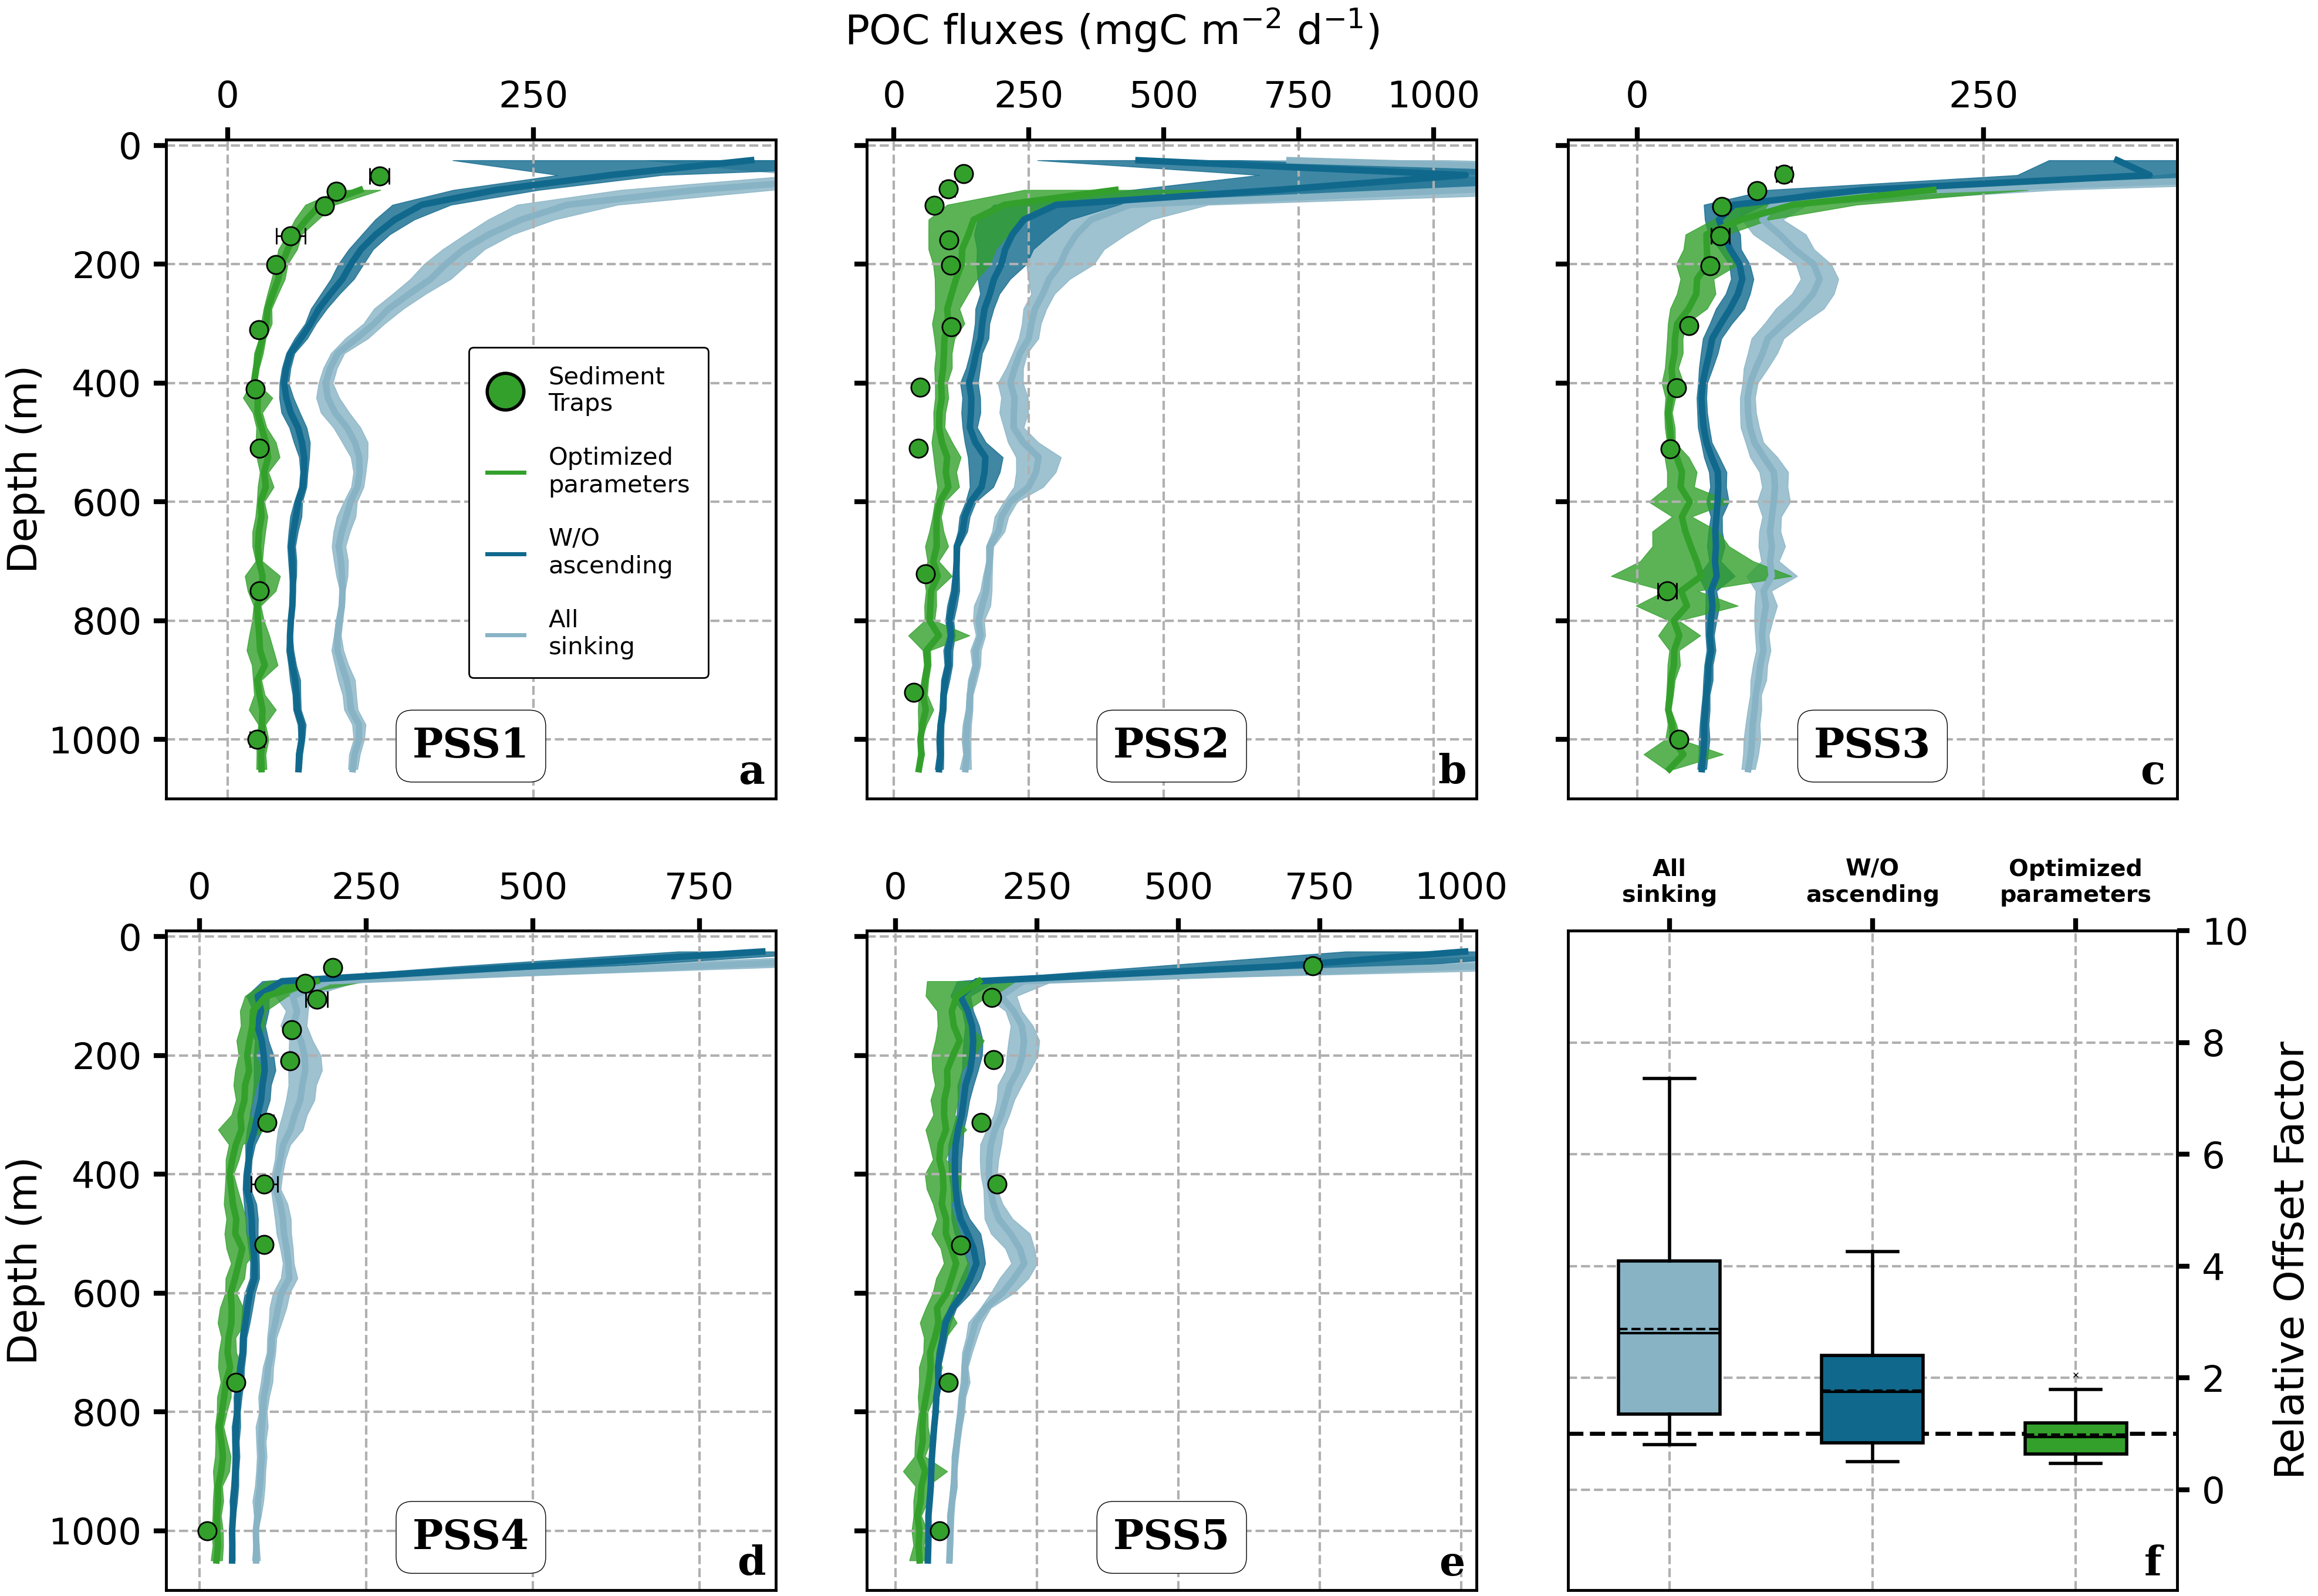

In [135]:
# Use first 5 letters of the alphabet
#sites = ['PSS1', 'PSS2', 'PSS3', 'PSS4', 'PSS5']
letters = list(string.ascii_lowercase[:len(sites)])  # ['A', 'B', 'C', 'D', 'E']
# Create dictionary mapping site -> letter
site_to_subplot = dict(zip(sites, letters))

# Define subplot grid (adjust automatically)
nrows = 2
ncols = 3
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(40, 30))
axes = axes.flatten()

# Common plot settings 
color_uvp_down = '#10698D'
color_uvp_usual = '#87B3C5'
color_uvp_guidi = '#a50026'
color_uvp_opti = '#33a02c'
color_st = '#33a02c'

linewidth = 8
scatter_size = 15

# Set labels and ticks
size = 50
l, w, pad = 15, 6, 15


for i, site in enumerate(sites):
    df_site = mean_PSS_total_POC_fluxes[mean_PSS_total_POC_fluxes['Site'] == site]
    trap_site = ST_POC_fluxes[ST_POC_fluxes['Site'] == site]
    df_opti = uvp_optimized[uvp_optimized['Site'] == site]
    ax = axes[i]

    # Plot net uvp fluxes (with ascending and descending)
    #ax.plot(df_site['net_POC_fluxes_mgC_m2_d'], df_site['Pressure [dbar]'], marker='o', color = 'blue', linestyle='-', label = 'Net')
    
    # Plot POC fluxes considering all particles sinking
    ax.plot(df_site['Usual_POC_fluxes_mgC_m2_d_alldredge_mean'], df_site['Pressure [dbar]'], color = color_uvp_usual, linestyle='-', lw = linewidth, label = 'All particles sinking')
    
    ax.fill_betweenx(
            df_site['Pressure [dbar]'],
            df_site['Usual_POC_fluxes_mgC_m2_d_alldredge_mean'] - df_site['Usual_POC_fluxes_mgC_m2_d_alldredge_std'],
            df_site['Usual_POC_fluxes_mgC_m2_d_alldredge_mean'] + df_site['Usual_POC_fluxes_mgC_m2_d_alldredge_std'],
            color=color_uvp_usual,
            alpha=0.8
        )
    
    # Plot downward POC fluxes
    ax.plot(df_site['desc_POC_fluxes_mgC_m2_d_alldredge_mean'], df_site['Pressure [dbar]'], color = color_uvp_down, linestyle='-', lw = linewidth, label = 'Downward')

    ax.fill_betweenx(
            df_site['Pressure [dbar]'],
            df_site['desc_POC_fluxes_mgC_m2_d_alldredge_mean'] - df_site['desc_POC_fluxes_mgC_m2_d_alldredge_std'],
            df_site['desc_POC_fluxes_mgC_m2_d_alldredge_mean'] + df_site['desc_POC_fluxes_mgC_m2_d_alldredge_std'],
            color=color_uvp_down,
            alpha=0.8
        )
    
    # Plot optimized uvp fluxes
    ax.plot(df_opti['Flux_opti_mean'], df_opti['Pressure [dbar]'], linestyle='-', color = color_uvp_opti, lw = linewidth, label = 'Optimized with Sediment Traps')

    ax.fill_betweenx(
            df_opti['Pressure [dbar]'],
            df_opti['Flux_opti_mean'] - df_opti['Flux_opti_std'],
            df_opti['Flux_opti_mean'] + df_opti['Flux_opti_std'],
            color=color_uvp_opti,
            alpha=0.8
        )


    
    # Plot sediment trap data
    ax.errorbar(
        trap_site['Mean_flux_mg_m2_d'],
        trap_site['Pressure [dbar]'],
        xerr=trap_site['Sd_flux'],
        fmt='o',
        color=color_st,
        markeredgecolor = 'black',
        ecolor='black',
        elinewidth=2,
        capsize=10,
        markersize=scatter_size*1.5,
        markeredgewidth=2,
        label='Sediment Trap')
    ax.set_ylim(-10, 1100)
    ax.invert_yaxis()  # Depth increases downward
    #ax.set_title(f'{site}', fontsize=size)
    ax.grid(True, which="both", ls="--", linewidth=3, zorder = 1, alpha=1)
    #ax.legend()
    
    if i % ncols == 0:
        ax.set_ylabel('Depth (m)', size=size)
    else:
        ax.set_ylabel('')
        ax.tick_params(axis='y', labelleft=False)
        
    if i < ncols:
        ax.set_xlabel('')#ax.set_xlabel(r'POC fluxes (mgC m$^{-2}$ d$^{-1}$)', size=size, labelpad=30)
    else:
        ax.set_xlabel('')

    ax.xaxis.set_ticks_position('top')
    ax.xaxis.set_label_position('top')
    ax.set_xticks(np.arange(0, df_site['desc_POC_fluxes_mgC_m2_d_alldredge_mean'].max()+20, 250))
    ax.tick_params(axis='y', labelsize=size-5, pad=pad, length=l, width=w)
    ax.tick_params(axis='x', labelsize=size-5, pad=pad, length=l, width=w, top=True, labeltop=True, bottom=False, labelbottom=False)
    ax.set_xlim(-50, df_site['desc_POC_fluxes_mgC_m2_d_alldredge_mean'].max()+20)
     
    # subplot indice
    ax.text(0.96,  0.04, f'{site_to_subplot[site]}', color='black', 
                     fontsize=size, ha='center', va='center', fontstyle='normal', fontfamily = 'serif', fontweight='bold',
                     alpha = 1, transform=ax.transAxes)#facecolor='white'

    # PSS
    pss_label = site.split('_')[-1]
    ax.text(0.5,  0.08, f'{pss_label}', color='black', 
                     fontsize=size, ha='center', va='center', fontstyle='normal', fontfamily = 'serif', fontweight='bold',
                     alpha = 1, transform=ax.transAxes, bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.4'))#facecolor='white'
    
# --- Global % offset plot in 3rd row, 2nd column ---
offset_ax_index = 5  # 3rd row, 2nd column (0-indexed)

# Mapping of variable to color
var_to_color = {
    'opti_Rel_offset': color_uvp_opti,
    'Only_sink_Rel_offset': color_uvp_down,
    'Usual_Rel_offset': color_uvp_usual
    #'guidi_Rel_offset': color_uvp_guidi
}

if offset_ax_index < len(axes):
    ax_offset = axes[offset_ax_index]
    
    
    #for i, y in enumerate(data_for_plot):
    for i, var in enumerate(cols_ordered):
        y = data_for_plot_alldredge[i]
        if len(y) == 0:
            continue
    
        # IQR filtering for outliers
        Q1 = np.percentile(y, 25)
        Q3 = np.percentile(y, 75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        y_filtered = [val for val in y if lower_bound <= val <= upper_bound]
        
        # Characteristics of the boxplot 
        boxprops = dict(linewidth = linewidth/2, color = 'black') # box
        whiskerprops = dict(linewidth = linewidth/2, color = 'black') # moustache
        flierprops = dict(marker = 'x', alpha = 1, markerfacecolor = 'black', markeredgecolor='black') # outliers
        capprops = dict(linewidth = linewidth/2, color = 'black') # horizontal line at the end of the boxplot 
        meanprops = dict(linestyle='--', linewidth = 3, color='black', label = 'Mean') # mean
        medianprops = dict(linestyle='-', linewidth = 3, color='black', label = 'Median') # median
        
        # Boxplot
        bp = ax_offset.boxplot(
            y_filtered,
            positions=[i],
            widths=0.5,
            patch_artist=True,
            showmeans=True,
            meanline=True,
            boxprops=boxprops,
            whiskerprops=whiskerprops,
            capprops=capprops,
            flierprops=flierprops,
            medianprops=medianprops,
            meanprops=meanprops,
            zorder = 3)

        for patch in bp['boxes']:
            patch.set_facecolor(var_to_color[var])
        
    # Set x-axis
    ax_offset.set_xticks(range(len(labels_ordered)))
    ax_offset.set_xticklabels(labels_ordered, rotation=0)
    ax_offset.xaxis.set_ticks_position('top')
    ax_offset.xaxis.set_label_position('top')
    for tick in ax_offset.get_xticklabels():
        tick.set_fontweight('bold')      
    
    # Move y-axis to the right
    ax_offset.yaxis.set_label_position("right")
    ax_offset.yaxis.tick_right()
    ax_offset.tick_params(axis='y', labelsize=size-5, pad=pad, length=l, width=w)

    ax_offset.tick_params(axis='x', labelsize=size/1.75, pad=pad, length=l, width=w)
            
    # Y-axis label
    ax_offset.set_ylabel(r'Relative Offset Factor', fontsize=size, labelpad=30)
    ax_offset.set_ylim(-1.8, 10)
    
    # Grid
    ax_offset.grid(True, which="both", ls="--", linewidth=3, zorder = 1, alpha=1)

    # Reference line at perfect match
    ax_offset.axhline(y=1, color='black', linestyle='--', linewidth=5, zorder = 2, alpha = 1)
            
    # subplot indice
    ax_offset.text(0.96,  0.04, 'f', color='black', 
                     fontsize=size, ha='center', va='center', fontstyle='normal', fontfamily = 'serif', fontweight='bold',
                     alpha = 1, transform=ax_offset.transAxes)#facecolor='white'

fig.supxlabel(r'POC fluxes (mgC m$^{-2}$ d$^{-1}$)', 
              fontsize=size, 
              y=0.91, x = 0.475) 

TS_flux = mlines.Line2D([], [], color = color_st, alpha = 1, marker = 'o', markersize=45, markeredgewidth=4, markeredgecolor='black', linestyle= '', linewidth=5, label='Sediment\nTraps')
UVP_down = mlines.Line2D([], [], color = color_uvp_down, alpha = 1, linestyle= '-', linewidth=5, label='W/O\nascending')
UVP_usual = mlines.Line2D([], [], color = color_uvp_usual, alpha = 1, linestyle= '-', linewidth=5, label='All\nsinking')
#UVP_guidi = mlines.Line2D([], [], color = color_uvp_guidi, alpha = 1, linestyle= '-', linewidth=5, label='Conventional\nparameters')
UVP_opti = mlines.Line2D([], [], color = color_uvp_opti, alpha = 1, linestyle= '-', linewidth=5, label='Optimized\nparameters')

glob_legend = fig.legend(handles=[TS_flux, UVP_opti, UVP_down, UVP_usual], fontsize=30, labelspacing=1.25, markerscale=1, borderpad=0.75, #UVP_guidi
                         frameon = True, loc='upper center', ncol=1, bbox_to_anchor=(0.252, 0.75), edgecolor='black', 
                         handletextpad=1, handlelength=1.5, fancybox=True, shadow=False, framealpha=1)

for text in glob_legend.get_texts():
    text.set_ha('left')  # horizontal alignment
    text.set_multialignment('left')  # for multi-line text

glob_legend.get_frame().set_linewidth(2)

axes_flat = axes.flatten()

for ax in axes_flat:
    for spine in ax.spines.values():
        spine.set_linewidth(3.5)
        
plt.tight_layout(rect=[0, 0, 0.99, 0.9]) #rect=[left, bottom, right, top]

plt.subplots_adjust(wspace=0.15, hspace=0.2)

plt.savefig('/home/aaccardo/these_alex/Papers/Rising_stars/Figure_S12/Figure_S12.png', dpi = 300)

plt.show()

In [128]:
sites

array(['ST01_PSS1', 'ST11_PSS2', 'ST25_PSS3', 'ST32_PSS4', 'ST42_PSS5'],
      dtype=object)